# 3D Tumor Growth Simulation

Variables:
- oxygen(x,t): oxygen *concentration* field, initialised to O_MAX everywhere. Cells deplete it via Michaelis-Menten kinetics
  - diffusion redistributes it;
  - angiogenesis restores it.
- C = 1 - O/O_MAX : hypoxia ratio (0 = well-oxygenated, 1 = fully hypoxic)
  - High oxygen  → C near 0 → low death, high division
  - Low oxygen   → C near 1 → high death, low division (hypoxia)
- d  = alpha * C             (cell death probability)
- b  = beta * (1 + gamma - C) (cell division probability)
- $\phi$(x,t): pro-angiogenic factor field
- R  = b/d : division-to-death ratio (strange attractor axis)
- Metastasis: if a cell tries to divide into an occupied site, it performs a random walk outward until it finds an empty site. 
    If the last occupied site has only 1 neighbour, the daughter cell detaches → metastatic event.
- Angiogenic switch: when population reaches N_A, cells start producing phi on the outer shell, which diffuses and restores oxygen.
- Necrosis: 
  - Cells with O < O_HYPOXIA become hypoxic and start producing phi; 
  - Cells with O < O_NECROSIS for too long, they become necrotic and stop consuming oxygen. 
- Necrotic cells are gradually cleared, creating space for new growth.
- Condensing vs non-condensing phenotypes: 
  - condensing cells (gamma > 0) have higher division and death rates, leading to more dynamic turnover and a more compact tumor; 
  - non-condensing cells (gamma < 0) have lower rates, leading to slower growth and a more diffuse morphology. 
  - This models the trade-off between aggressive proliferation and mechanical pressure in tumor evolution.
- Parameter sweep: we can run multiple simulations in parallel with different (alpha, beta) pairs to explore how the balance of growth and death rates affects tumor dynamics and metastatic potential.
---
---
## 1-Load packages

In [7]:
from __future__ import annotations

import os
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed

## 2-Initial Definitions

In [8]:
# ─────────────────────────────────────────────
#  SIMULATION PARAMETERS
# ─────────────────────────────────────────────
L     = 40          # grid side length (nodes)
GAMMA = 0.1         # condensing factor (+ for condensing, - for non-condensing)
N_A   = 500         # cell count at which angiogenic switch turns on
D_OX  = 2.0         # oxygen diffusion coefficient
D_CH  = 1000.0      # pro-angiogenic factor diffusion coefficient
DELTA = 0.05        # fraction of O_MAX restored per unit phi per step
N_OX  = 100         # oxygen diffusion time steps per simulation step
N_CH  = 50          # chemokine diffusion time steps per simulation step
DT    = 0.0001      # diffusion time step
DX    = 1.0         # lattice spacing

# ── Oxygen metabolism (Michaelis-Menten kinetics) ────────────────────────────
O_MAX = 1.0         # maximum oxygen concentration (normalised)
V_MAX = 0.17        # maximum cellular oxygen uptake rate per step
K_M   = 0.1         # Michaelis-Menten half-saturation constant

# ── Necrotic threshold 
O_HYPOXIA = 0.15     # Cells with O < O_HYPOXIA become hypoxic and start producing pro-angiogenic factors
O_NECROSIS = 0.05   # Cells with O < O_NECROSIS become necrotic and stop consuming O)
NECROSIS_DELAY = 4  # Slow death under hypoxia
NECROTIC_CLEAR_RATE = 0.001  # Fraction of necrotic cells cleared per step (simulate immune clearance)

# Tunable intrinsic parameters (try different combos!)
ALPHA = 0.3         # resistance factor (max death probability)
BETA  = 0.7         # growth factor (max division probability)

MAX_SIM_STEPS = 40    # simulation time steps
SEED    = 42
SWEEP_TIMEOUT = 600  # seconds before a parallel combo is cancelled

# ─────────────────────────────────────────────
#  CELL REPRESENTATION
# ─────────────────────────────────────────────
class Cell:
    """A single tumor cell on the lattice."""
    def __init__(self, x, y, z, condensing: bool):
        self.x = x
        self.y = y
        self.z = z
        self.condensing = condensing          # True = condensing, False = non-condensing
        self.gamma = GAMMA if condensing else -GAMMA
        self.alive = True
        self.necrotic = False
        self.hypoxia_time = 0

    @property
    def pos(self):
        return (self.x, self.y, self.z)

# ─────────────────────────────────────────────
#  NEIGHBOR OFFSETS (1st + 2nd order, total 18)
# ─────────────────────────────────────────────
def get_neighbors_18():
    """Return all 1st and 2nd order neighbor offsets in a cubic lattice (18 total)."""
    offsets = []
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            for dz in [-1, 0, 1]:
                n_nonzero = (dx != 0) + (dy != 0) + (dz != 0)
                if n_nonzero == 1 or n_nonzero == 2:   # 1st order (6) + 2nd order (12)
                    offsets.append((dx, dy, dz))
    return offsets

NEIGHBORS_18 = get_neighbors_18()
NEIGHBORS_6  = [(1,0,0),(-1,0,0),(0,1,0),(0,-1,0),(0,0,1),(0,0,-1)]

# ─────────────────────────────────────────────
#  ADAPTIVE 3-D DIFFUSION (3D finite differences)
# ─────────────────────────────────────────────
def diffuse_3d(field: np.ndarray, D: float, n_steps: int,
               dt: float = DT, dx: float = DX) -> np.ndarray:
    """
    Explicit finite-difference 3-D diffusion with Neumann BCs.
 
    OPTIMISATION — adaptive Δt:
      The stability limit is  D·Δt/Δx² ≤ 1/6.
      The original code used Δt = 0.0001 which is far below the limit.
      We compute the largest stable Δt (with a 10 % safety margin) and
      reduce n_steps proportionally, keeping total diffusion time constant.
    """
    total_time = n_steps * dt                          # preserve intended physics
    dt_max     = (dx ** 2) / (6.0 * D) * 0.80         # 80% of stability limit
    n_opt      = max(1, int(np.ceil(total_time / dt_max)))
    dt_opt     = total_time / n_opt                    # exact step to hit total_time
 
    u      = field.copy()
    factor = D * dt_opt / dx ** 2
 
    for _ in range(n_opt):
        lap = (
            u[2:,   1:-1, 1:-1] + u[:-2,  1:-1, 1:-1] +
            u[1:-1, 2:,   1:-1] + u[1:-1, :-2,  1:-1] +
            u[1:-1, 1:-1, 2:  ] + u[1:-1, 1:-1, :-2  ] -
            6.0 * u[1:-1, 1:-1, 1:-1]
        )
        u[1:-1, 1:-1, 1:-1] += factor * lap
 
    return u

## 3-Main Simulation Class

In [9]:
class TumorSimulation:
    def __init__(self, L=L, alpha=ALPHA, beta=BETA, seed=SEED):
        self.L     = L
        self.alpha = alpha
        self.beta  = beta
        self.rng   = np.random.default_rng(seed)
        random.seed(seed)

        # Lattice: None = empty, Cell object = occupied
        self.lattice = np.full((L, L, L), None, dtype=object)

        # Continuous fields
        # oxygen: concentration field, starts fully oxygenated everywhere
        self.oxygen = np.ones((L, L, L)) * O_MAX
        self.phi    = np.zeros((L, L, L))   # pro-angiogenic factor

        # State tracking
        self.cells: list[Cell] = []
        self._cell_idx: dict[int, int] = {}
        self.angiogenic_on = False
        self.t             = 0

        # History for plotting
        self.history = {
            'population':        [],
            'metastatic_cells':  [],
            'avg_b':             [],
            'avg_d':             [],
            'avg_C':             [],
            'R_ratio':           [],
        }

        # Seed initial tumor cell at center
        cx, cy, cz = L // 2, L // 2, L // 2
        self._place_cell(cx, cy, cz)

    # ── Internal helpers ─────────────────────────────────────────────────────

    def _place_cell(self, x: int, y: int, z: int):
        """Create and place a new cell at (x,y,z)."""
        condensing = bool(self.rng.integers(0, 2))
        cell = Cell(x, y, z, condensing)
        idx  = len(self.cells)
        self.cells.append(cell)
        self._cell_idx[id(cell)] = idx
        self.lattice[x, y, z]   = cell

    def _remove_cell(self, cell: Cell):
        cell.alive = False
        self.lattice[cell.x, cell.y, cell.z] = None
 
        idx  = self._cell_idx.pop(id(cell))
        last = self.cells[-1]
        self.cells[idx] = last
        self._cell_idx[id(last)] = idx
        self.cells.pop()

    def _in_bounds(self, x, y, z):
        return 0 <= x < self.L and 0 <= y < self.L and 0 <= z < self.L

    # ── Probability equations ────────────────────────────────────

    def C_ratio(self, x, y, z) -> float:
        """
        Hypoxia ratio at position (x,y,z).
        C = 1 - O/O_MAX
          C → 0  when well-oxygenated  (low stress)
          C → 1  when fully hypoxic    (high stress)
        """
        O = float(self.oxygen[x, y, z])
        return float(np.clip(1.0 - O / O_MAX, 0.0, 1.0))

    def death_prob(self, cell: Cell) -> float:
        """Cell death probability: d = alpha * C."""
        C = self.C_ratio(cell.x, cell.y, cell.z)
        return self.alpha * C

    def division_prob(self, cell: Cell) -> float:
        """Cell division probability: b = beta * (1 + gamma - C)."""
        C = self.C_ratio(cell.x, cell.y, cell.z)
        val = self.beta * (1.0 + cell.gamma - C)
        if cell.hypoxia_time > 0:
            val *= 0.75  # Hypoxic cells divide more slowly
        return float(np.clip(val, 0.0, 1.0))

    # ── Angiogenic switch & diffusion (Sec. II B-D) ──────────────────────────

    def _consume_oxygen(self):
        """
        Vectorized Michaelis-Menten cellular oxygen uptake.
        Only occupied, non-necrotic lattice sites consume oxygen.
        Necrotic sites have their oxygen concentration set to zero
        Q(O) = V_MAX * O / (K_M + O)
        """
        # Build mask over the full grid using cell objects (not lattice attributes)
        living_mask  = np.zeros((self.L, self.L, self.L), dtype=np.float32)
        necrotic_mask = np.zeros((self.L, self.L, self.L), dtype=bool)
 
        for cell in self.cells:
            if cell.necrotic:
                necrotic_mask[cell.x, cell.y, cell.z] = True
            else:
                living_mask[cell.x, cell.y, cell.z]   = 1.0
 
        O = self.oxygen
        uptake = living_mask * (V_MAX * O / (K_M + O))
        self.oxygen = np.clip(O - uptake, 0.0, O_MAX)
        self.oxygen[necrotic_mask] = 0.0   # dead tissue does not perfuse

    def _update_oxygen(self):
        """
        Update oxygen field each simulation step.
        Physically correct order:
          1. Cellular uptake  — cells deplete local oxygen first
          2. Diffusion        — gradients re-equilibrate across the lattice
          3. Angiogenic supply — new vessels restore oxygen (only after switch)
        """
        # Oxygen uptake
        self._consume_oxygen()
        # Diffusion of oxygen field (true 3D diffusion using finite differences)
        self.oxygen = diffuse_3d(self.oxygen.copy(), D_OX, N_OX)
        # 3. Angiogenic oxygen supply
        if self.angiogenic_on:
            self.oxygen = np.clip(self.oxygen + DELTA * self.phi, 0.0, O_MAX)

    def _update_phi(self):
        """Release and diffuse pro-angiogenic factors from tumor shell."""
        N = len(self.cells)
        if N == 0:
            return
        # Inject phi on outer ~30% shell of occupied region
        cx = cy = cz = self.L // 2
        # Estimate tumor radius from cell count
        r_est = max(1.0, (3 * N / (4 * np.pi)) ** (1/3))
        shell_inner = r_est * 0.7

        # Vectorized extraction of cell positions
        xs = np.fromiter((c.x for c in self.cells), dtype=np.int32, count=N)
        ys = np.fromiter((c.y for c in self.cells), dtype=np.int32, count=N)
        zs = np.fromiter((c.z for c in self.cells), dtype=np.int32, count=N)
 
        dists = np.sqrt((xs - cx) ** 2 + (ys - cy) ** 2 + (zs - cz) ** 2)
        mask  = dists >= shell_inner
 
        # Scatter-add phi contribution at shell positions
        np.add.at(self.phi, (xs[mask], ys[mask], zs[mask]), (N / N_A) * 0.5)
 
        self.phi = diffuse_3d(self.phi, D_CH * DT, N_CH)
    
    def _update_necrosis(self):
        """
        Implements slow death under hypoxia.
        Cells accumulate hypoxia exposure before becoming necrotic.
        """
        alive_cells = [c for c in self.cells if c.alive]
        if not alive_cells:
            return
 
        n  = len(alive_cells)
        xs = np.fromiter((c.x for c in alive_cells), dtype=np.int32, count=n)
        ys = np.fromiter((c.y for c in alive_cells), dtype=np.int32, count=n)
        zs = np.fromiter((c.z for c in alive_cells), dtype=np.int32, count=n)
 
        O_vals = self.oxygen[xs, ys, zs]   # single vectorised index
 
        increments = np.where(O_vals < O_NECROSIS,  2,
                     np.where(O_vals < O_HYPOXIA,   1, -1))
 
        for i, cell in enumerate(alive_cells):
            cell.hypoxia_time = max(cell.hypoxia_time + int(increments[i]), 0)
            if cell.hypoxia_time >= NECROSIS_DELAY:
                cell.alive = False
                cell.necrotic = True
    
    def _clear_necrotic_cells(self, cell: Cell):
        """The immune system gradually clears necrotic cells, creating space for new growth."""
        if cell.necrotic and random.random() < NECROTIC_CLEAR_RATE:
            self._remove_cell(cell)

    # ── Choose neighbor for daughter cell ───────────────────────────────────

    def _choose_neighbor(self, x, y, z):
        """
        Pre-angiogenic: uniform random from 18 neighbors.
        Post-angiogenic: prefer neighbor with highest oxygen concentration (chemotaxis).
        """
        candidates = [
            (x + dx, y + dy, z + dz)
            for dx, dy, dz in NEIGHBORS_18
            if self._in_bounds(x + dx, y + dy, z + dz)
        ]
        if not candidates:
            return None

        if not self.angiogenic_on:
            return random.choice(candidates)
        else:
            # Chemotaxis: daughter cell moves toward highest oxygen concentration
            return max(candidates, key=lambda p: self.oxygen[p[0], p[1], p[2]])

    # ── Metastasis process (Sec. II E) ───────────────────────────────────────

    def _attempt_metastasis(self, x, y, z) -> bool:
        """
        Walk outward from (x,y,z) until an empty site is found.
        The walk is biased radially outward from the tumor center using
        weighted sampling: candidates farther from the center are preferred,
        modelling the mechanical pressure that pushes cells toward the surface.

        If the last occupied site has only a single 1st-order neighbour,
        the daughter cell detaches → metastatic event.
        Returns True if metastatic.
        """
        # Tumor center is fixed at the lattice midpoint
        center = np.array([self.L / 2, self.L / 2, self.L / 2])

        visited = set()
        current = (x, y, z)
        max_walk = 50

        for _ in range(max_walk):
            visited.add(current)
            cx, cy, cz = current

            # ── 1st-order occupied neighbours (used for detachment check)
            occ_neighbours_6 = [
                (cx + dx, cy + dy, cz + dz)
                for dx, dy, dz in NEIGHBORS_6
                if self._in_bounds(cx + dx, cy + dy, cz + dz)
                and self.lattice[cx + dx, cy + dy, cz + dz] is not None
            ]

            # ── Empty neighbours (any of 18): place daughter here if found
            empty_neighbours = [
                (cx + dx, cy + dy, cz + dz)
                for dx, dy, dz in NEIGHBORS_18
                if self._in_bounds(cx + dx, cy + dy, cz + dz)
                and self.lattice[cx + dx, cy + dy, cz + dz] is None
                and (cx + dx, cy + dy, cz + dz) not in visited
            ]
            if empty_neighbours:
                # Among empty sites, prefer the one furthest from center
                nx, ny, nz = max(
                    empty_neighbours,
                    key=lambda p: np.linalg.norm(np.array(p) - center)
                )
                if len(occ_neighbours_6) <= 1:
                    return True   # barely connected → detaches → metastatic
                self._place_cell(nx, ny, nz)
                return False

            # ── No empty site found: step to an occupied neighbour,
            #    biased toward whichever is furthest from the tumor center.
            #    We use distance as a unnormalised weight so the walk drifts
            #    outward rather than wandering arbitrarily through the bulk.
            occupied = [
                (cx + dx, cy + dy, cz + dz)
                for dx, dy, dz in NEIGHBORS_18
                if self._in_bounds(cx + dx, cy + dy, cz + dz)
                and self.lattice[cx + dx, cy + dy, cz + dz] is not None
                and (cx + dx, cy + dy, cz + dz) not in visited
            ]
            if not occupied:
                break

            # Compute radial distance of each candidate from center
            distances = np.array([
                np.linalg.norm(np.array(p) - center) for p in occupied
            ])
            # Shift so minimum weight is > 0, then normalise to a probability
            weights = distances - distances.min() + 1e-6
            weights /= weights.sum()

            chosen_idx = self.rng.choice(len(occupied), p=weights)
            current = occupied[chosen_idx]

        return False  # Failed to find empty site within max_walk steps → no metastasis

    # ── Simulation step ──────────────────────────────────────────────────

    def step(self):
        """Advance simulation by one time step."""
        N = len(self.cells)

        # ── Check angiogenic switch
        if not self.angiogenic_on and N >= N_A:
            self.angiogenic_on = True
            print(f"  [t={self.t}] Angiogenic switch ON  (N={N})")

        # ── Update diffusion fields
        self._update_oxygen()
        if self.angiogenic_on:
            self._update_phi()

        # ── Necrosis update
        self._update_necrosis()

        # ── Cell fate decisions (iterate over copy to avoid mutation issues)
        cells_snapshot = list(self.cells)
        metastatic_count = 0
        b_vals, d_vals, C_vals = [], [], []

        for cell in cells_snapshot:
            if not cell.alive:
                if cell.necrotic:
                    self._clear_necrotic_cells(cell)
                continue

            d = self.death_prob(cell)
            b = self.division_prob(cell)
            C = self.C_ratio(cell.x, cell.y, cell.z)
            b_vals.append(b)
            d_vals.append(d)
            C_vals.append(C)

            roll = self.rng.random()

            if roll < d:
                # Cell death
                self._remove_cell(cell)

            elif roll < d + b:
                # Cell division
                nbr = self._choose_neighbor(cell.x, cell.y, cell.z)
                if nbr is None:
                    continue
                nx, ny, nz = nbr
                if self.lattice[nx, ny, nz] is None:
                    # Empty → place daughter directly
                    self._place_cell(nx, ny, nz)
                else:
                    # Occupied → trigger metastasis walk
                    is_meta = self._attempt_metastasis(nx, ny, nz)
                    if is_meta:
                        metastatic_count += 1

        # ── Record history
        avg_b = float(np.mean(b_vals)) if b_vals else 0.0
        avg_d = float(np.mean(d_vals)) if d_vals else 0.0
        avg_C = float(np.mean(C_vals)) if C_vals else 0.0
        R = avg_b / avg_d if avg_d > 1e-9 else float('inf')

        self.history['population'].append(len(self.cells))
        self.history['metastatic_cells'].append(metastatic_count)
        self.history['avg_b'].append(avg_b)
        self.history['avg_d'].append(avg_d)
        self.history['avg_C'].append(avg_C)
        self.history['R_ratio'].append(min(R, 50))  # clip for plotting

        self.t += 1

    def run(self, n_steps: int = MAX_SIM_STEPS, verbose: bool = True):
        for step_i in range(n_steps):
            self.step()
            if verbose and (step_i % 5 == 0 or step_i == n_steps - 1):
                N = len(self.cells)
                meta = self.history['metastatic_cells'][-1]
                b = self.history['avg_b'][-1]
                d = self.history['avg_d'][-1]
                print(f"  t={self.t:3d} | N={N:5d} | meta={meta:3d} | "
                      f"<b>={b:.3f} | <d>={d:.3f} | angio={'ON' if self.angiogenic_on else 'off'}")

### 3.1- PARALLEL PARAMETER SWEEP  (top-level so it is picklable)

In [10]:
# ─────────────────────────────────────────────
# PARALLEL PARAMETER SWEEP  (top-level so it is picklable)
# ─────────────────────────────────────────────
def _run_combo(args):
    """Worker function — must be top-level for multiprocessing pickling."""
    alpha_i, beta_i, n_steps, seed = args
    sim = TumorSimulation(L=L, alpha=alpha_i, beta=beta_i, seed=seed)
    sim.run(n_steps=n_steps, verbose=False)
    return alpha_i, beta_i, sim.history['population'], len(sim.cells), \
           sum(sim.history['metastatic_cells'])
 
 
def run_parameter_sweep(combos, n_steps=MAX_SIM_STEPS, seed=SEED, max_workers=None):
    """
    Runs each (alpha, beta) combo in parallel.
    - In a Jupyter notebook: uses ThreadPoolExecutor (avoids BrokenProcessPool).
    - As a .py script under __main__: uses ProcessPoolExecutor for true parallelism.
    """
    args    = [(a, b, n_steps, seed) for a, b in combos]
    results = {}

    in_jupyter = 'ipykernel' in sys.modules
    Executor   = ThreadPoolExecutor if in_jupyter else ProcessPoolExecutor

    with Executor(max_workers=max_workers) as pool:
        futures = {pool.submit(_run_combo, a): a for a in args}
        for fut in as_completed(futures):
            alpha_i, beta_i = futures[fut][:2]
            try:
                alpha_i, beta_i, pops, final_N, total_meta = fut.result(timeout=SWEEP_TIMEOUT)
                results[(alpha_i, beta_i)] = pops
                print(f"  α={alpha_i}, β={beta_i}: final N={final_N}, meta={total_meta}")
            except TimeoutError:
                print(f"  α={alpha_i}, β={beta_i}: TIMED OUT after {SWEEP_TIMEOUT}s — skipped")
                fut.cancel()
            except Exception as e:
                print(f"  α={alpha_i}, β={beta_i}: ERROR — {e}")

    return results

## 4-Plotting

In [11]:
def plot_results(sim: TumorSimulation, fig_path: str = None):
    h = sim.history
    t = np.arange(1, len(h['population']) + 1)
 
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(f"Tumor Simulation  (α={sim.alpha}, β={BETA}, L={sim.L})", fontsize=12)
 
    ax = axes[0, 0]
    ax.plot(t, h['population'], color='steelblue', lw=2)
    if sim.angiogenic_on:
        ax.axhline(N_A, color='red', ls='--', lw=1, label=f'Angiogenic switch N={N_A}')
        ax.legend(fontsize=8)
    ax.set_title('Tumor Cell Population'); ax.set_xlabel('Simulation time'); ax.set_ylabel('N cells')
 
    ax = axes[0, 1]
    ax.plot(t, h['avg_b'], color='green',   lw=2, label='<b> division')
    ax.plot(t, h['avg_d'], color='crimson', lw=2, label='<d> death')
    ax.set_title('Mean Cell Probabilities'); ax.set_xlabel('Simulation time')
    ax.set_ylabel('Probability'); ax.legend(fontsize=8); ax.set_ylim(0, 1)
 
    ax = axes[0, 2]
    ax.plot(t, h['avg_C'], color='orange', lw=2)
    ax.axhline(1.0, color='red', ls='--', lw=1, label='Hypoxia threshold (C=1)')
    ax.set_title('Mean Hypoxia Ratio  C = 1 − O/O_max')
    ax.set_xlabel('Simulation time'); ax.set_ylabel('C'); ax.legend(fontsize=8)
 
    ax = axes[1, 0]
    ax.bar(t, h['metastatic_cells'], color='purple', alpha=0.7)
    ax.set_title('Metastatic Events per Step')
    ax.set_xlabel('Simulation time'); ax.set_ylabel('Detached cells')
 
    ax = axes[1, 1]
    ax.plot(t, h['R_ratio'], color='teal', lw=2)
    ax.set_title('Ratio R = <b>/<d>'); ax.set_xlabel('Simulation time'); ax.set_ylabel('R')
 
    ax = fig.add_subplot(2, 3, 6, projection='3d')
    xs = [c.x for c in sim.cells]; ys = [c.y for c in sim.cells]; zs = [c.z for c in sim.cells]
    colors = ['black' if c.necrotic else 'royalblue' if c.condensing else 'tomato' for c in sim.cells]
    ax.scatter(xs, ys, zs, c=colors, s=2, alpha=0.5)
    ax.set_title('Cell Positions\n(black=necrotic, blue=condensing, red=non-condensing)')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
 
    plt.tight_layout()
    if fig_path:
        plt.savefig(fig_path, dpi=120, bbox_inches='tight')
        print(f"\nFigure saved → {fig_path}")
    plt.show()
 
 
def plot_oxygen_slice(sim: TumorSimulation, fig_path: str = None):
    z_mid = sim.L // 2
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Diffusion fields at z={z_mid}  (t={sim.t})", fontsize=12)
 
    im1 = axes[0].imshow(sim.oxygen[:, :, z_mid].T, origin='lower',
                         cmap='hot', aspect='equal', vmin=0, vmax=O_MAX)
    axes[0].set_title('Oxygen concentration O(x,y)'); plt.colorbar(im1, ax=axes[0])
 
    im2 = axes[1].imshow(sim.phi[:, :, z_mid].T, origin='lower',
                         cmap='plasma', aspect='equal')
    axes[1].set_title('Pro-angiogenic factor φ(x,y)'); plt.colorbar(im2, ax=axes[1])
 
    plt.tight_layout()
    if fig_path:
        plt.savefig(fig_path, dpi=120, bbox_inches='tight')
        print(f"Diffusion figure saved → {fig_path}")
    plt.show()
 
 
def plot_comparison(sweep_results: dict, fig_path: str = None):
    fig, ax = plt.subplots(figsize=(10, 6))
    for (alpha_i, beta_i), pops in sorted(sweep_results.items()):
        t = range(1, len(pops) + 1)
        ax.plot(t, pops, label=f'α={alpha_i}, β={beta_i}', lw=2)
    ax.axhline(N_A, color='k', ls='--', lw=1, label=f'Angiogenic switch N={N_A}')
    ax.set_title('Population of simulated tumor evolutions for different (α, β) pairs')
    ax.set_xlabel('Simulation time'); ax.set_ylabel('Population'); ax.legend()
    plt.tight_layout()
    if fig_path:
        fig.savefig(fig_path, dpi=120, bbox_inches='tight')
        print(f"\nComparison figure saved → {fig_path}")
    plt.show()

## 5-VISUALIZATION

3D Tumor Growth Simulation
Parameters: α=0.3, β=0.7, L=40
Angiogenic switch at N=500 cells
  t=  1 | N=    2 | meta=  0 | <b>=0.535 | <d>=0.041 | angio=off
  t=  6 | N=    6 | meta=  0 | <b>=0.456 | <d>=0.095 | angio=off
  t= 11 | N=   21 | meta=  0 | <b>=0.403 | <d>=0.126 | angio=off
  t= 16 | N=   57 | meta=  2 | <b>=0.414 | <d>=0.120 | angio=off
  t= 21 | N=  126 | meta=  3 | <b>=0.390 | <d>=0.131 | angio=off
  t= 26 | N=  328 | meta= 10 | <b>=0.387 | <d>=0.136 | angio=off
  [t=29] Angiogenic switch ON  (N=546)
  t= 31 | N=  825 | meta= 15 | <b>=0.405 | <d>=0.124 | angio=ON
  t= 36 | N= 4235 | meta=218 | <b>=0.580 | <d>=0.051 | angio=ON
  t= 40 | N=25377 | meta= 37 | <b>=0.639 | <d>=0.027 | angio=ON

Final population      : 25377 cells
Total metastatic events: 1049
Angiogenic switch triggered: True

Figure saved → results/tumor_results.png


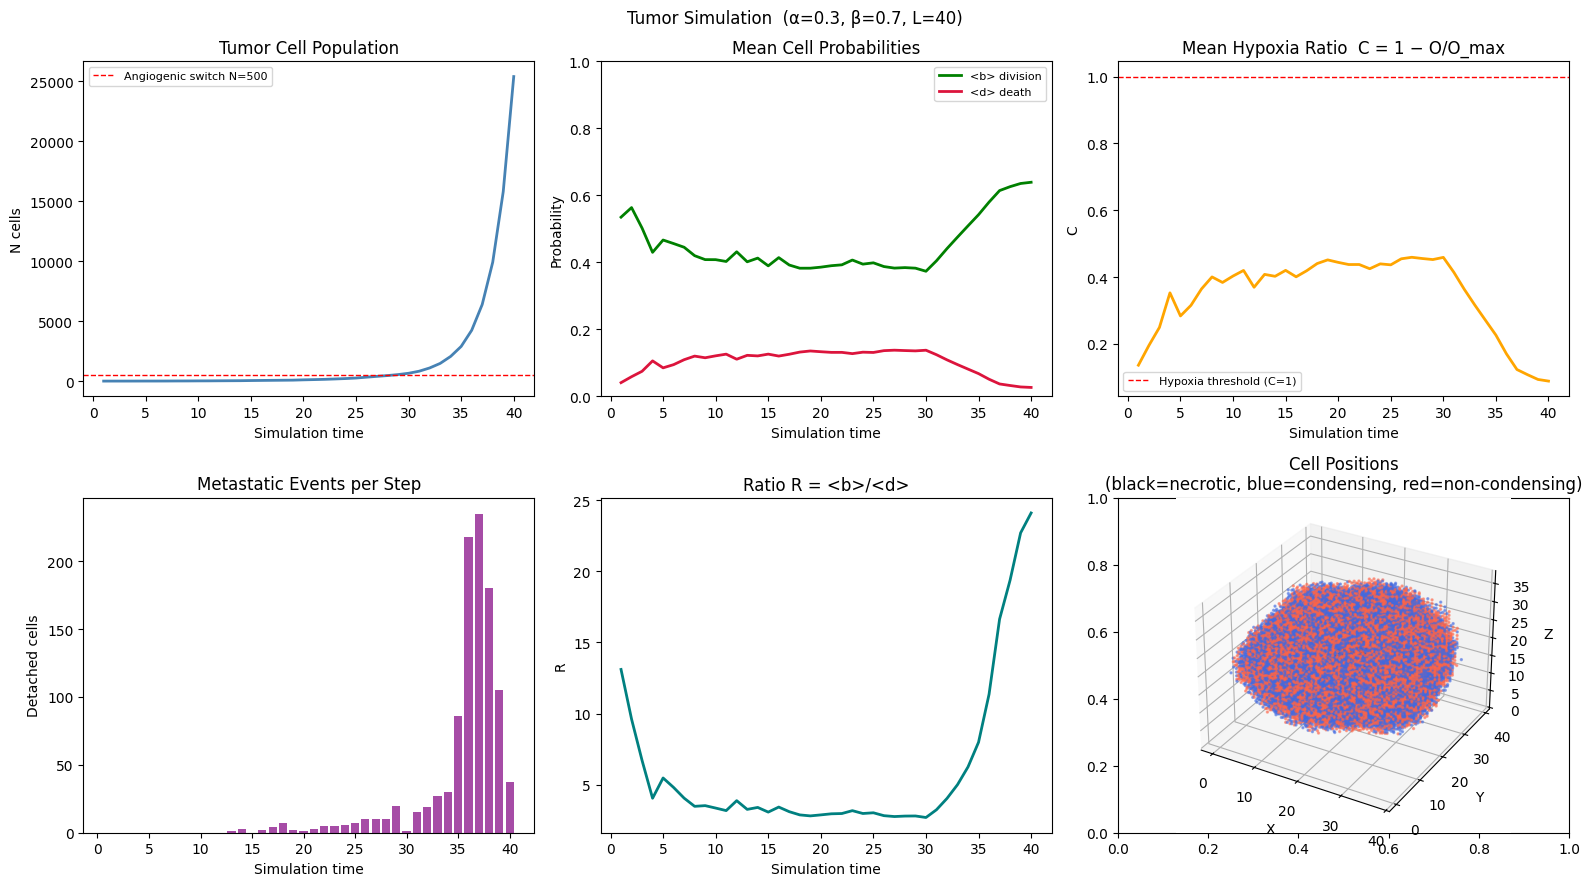

Diffusion figure saved → results/tumor_diffusion.png


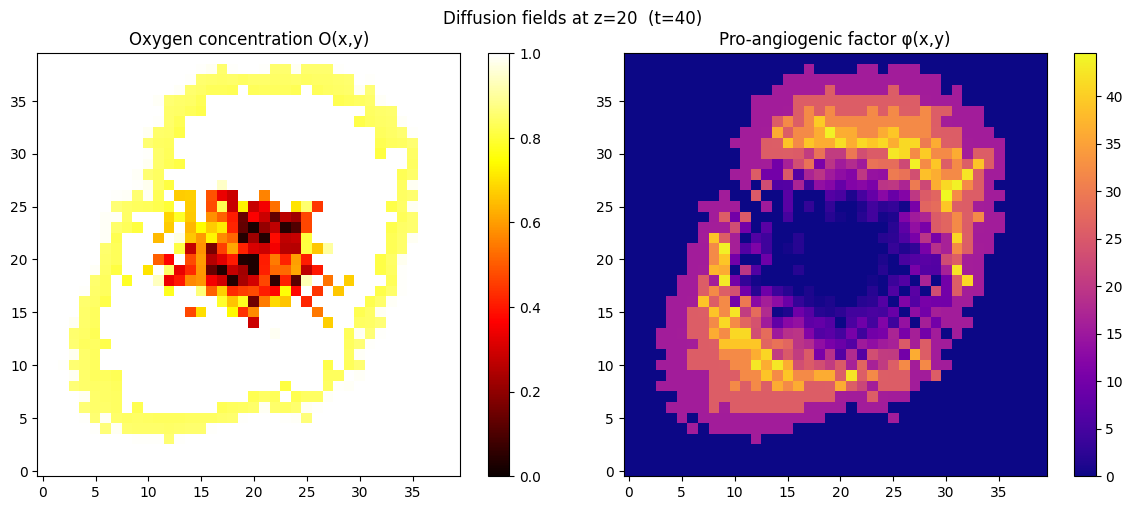


--- Comparing parameter pairs (α, β) in parallel ---
  [t=17] Angiogenic switch ON  (N=512)
  [t=22] Angiogenic switch ON  (N=588)
  α=0.3, β=0.5: final N=0, meta=0
  α=0.7, β=0.5: final N=0, meta=0
  [t=27] Angiogenic switch ON  (N=571)
  α=0.3, β=0.7: final N=39509, meta=870
  α=0.7, β=0.9: final N=62400, meta=1332
  α=0.3, β=0.9: final N=62856, meta=361

Comparison figure saved → results/tumor_comparison.png


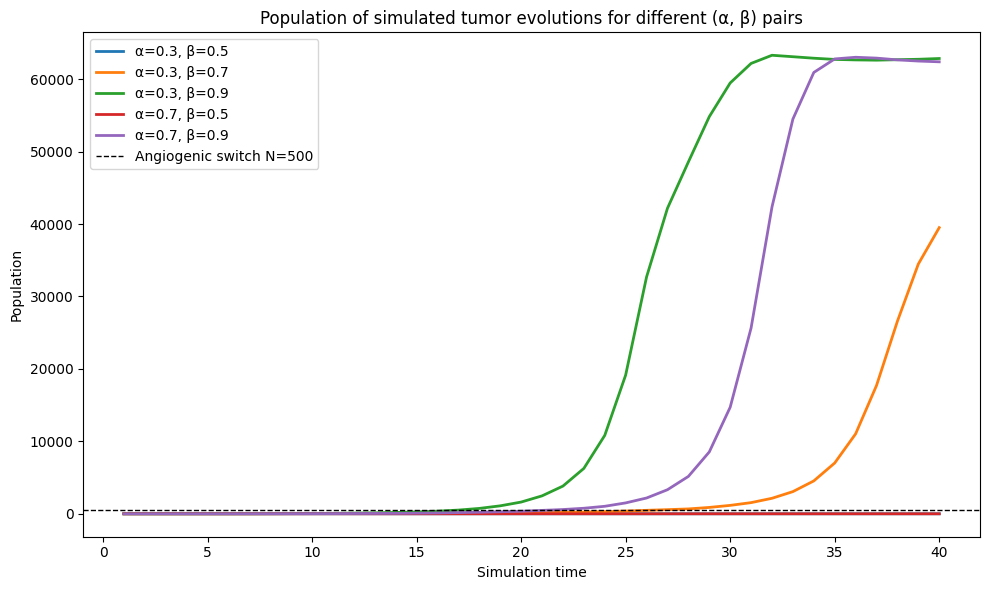

In [12]:
if __name__ == '__main__':
    print("=" * 60)
    print("3D Tumor Growth Simulation")
    print(f"Parameters: α={ALPHA}, β={BETA}, L={L}")
    print(f"Angiogenic switch at N={N_A} cells")
    print("=" * 60)
 
    # ── Single reference run
    sim = TumorSimulation(L=L, alpha=ALPHA, beta=BETA, seed=SEED)
    sim.run(n_steps=MAX_SIM_STEPS, verbose=True)
    print(f"\nFinal population      : {len(sim.cells)} cells")
    print(f"Total metastatic events: {sum(sim.history['metastatic_cells'])}")
    print(f"Angiogenic switch triggered: {sim.angiogenic_on}")
 
    plot_results(sim,        fig_path='results/tumor_results.png')
    plot_oxygen_slice(sim,   fig_path='results/tumor_diffusion.png')
 
    # ── Parallel parameter sweep  (runs all combos concurrently)
    print("\n--- Comparing parameter pairs (α, β) in parallel ---")
    combos = [(0.3, 0.5), (0.3, 0.7), (0.3, 0.9), (0.7, 0.5), (0.7, 0.9)]
    sweep  = run_parameter_sweep(combos, n_steps=MAX_SIM_STEPS, seed=SEED)
    plot_comparison(sweep, fig_path='results/tumor_comparison.png')